# Chapter 9. RNN
- 텍스트와 시계열 데이터 같은 순차 데이터에 잘 맞는 순환 신경망의 개념과 구성 요소
- 케라스 API로 기본적인 순환 신경망에서 고급 순환 신경망을 만들어 영화 감상평을 분류하는 작업에 적용
- 순환 신경망에서 발생하는 문제점과 이를 극복하기 위한 해결책 확인

In [2]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
from sklearn.model_selection import train_test_split
import keras
from keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from IPython.display import display
from keras.datasets import imdb
import numpy as np
import matplotlib.pyplot as plt
print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

keras.utils.set_random_seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

2025-12-03 16:42:44.107010: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-03 16:42:44.526389: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 16:42:46.642639: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
print(tf.config.list_physical_devices('GPU'))
print(tf.test.is_built_with_cuda())

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [4]:
from tensorflow.python.platform import build_info as build

print(build.build_info)

OrderedDict([('cpu_compiler', 'clang 18'), ('cuda_compute_capabilities', ['sm_60', 'sm_70', 'sm_80', 'sm_89', 'compute_90']), ('cuda_version', '12.5.1'), ('cudnn_version', '9'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', False)])


## 09-1 순차 데이터와 순환 신경망 
### 순차 데이터
- 텍스트나 시계열 데이터 time series data와 같이 순서에 의미가 있는 데이터를 의미
- 시계열 데이터와 문장 데이터가 이에 해당

![alt text](image.png)


- 피드포워드 신경망 feedforward neural network FFNN : 입력 데이터의 흐름이 앞으로만 전달되는 신경망 DNN, CNN이 해당

### 순환 신경망 Recurrent neural network, RNN
- 이전 데이터의 정보가 다음 출력값에 영향을 미치는 신경망 알고리즘
- 입력에 어떤 가중치를 곱하고 활성화 함수를 통과시킨 후, 다음 층으로 보낸 후 층의 출력 (즉 은닉 상태)을 다음 타임 스텝에 재사용

![alt text](./appendix/ch9/image-1.png)

- 타임스텝 time step : 샘플을 처리하는 한 단계
- 셀 Cell : 순환 신경망내에서 층을 지칭할 때 쓰는 말, 은닉 상태가 모든 뉴런에 순환 되기 때문에 새로운 용어로서 신경망을 지칭하는 용어를 만들어냄
- 은닉 상태 hidden state : 셀의 출력
(위 그림에서 $O_c$에는 $A$에 대한 정보보다 $B$에 대한 정보가 더 많음)

- 활성화 함수로는 하이퍼볼릭 탄젠트 hyperbolic tangent 함수인 tanh가 많이 사용

![alt text](./appendix/ch9/image-2.png)

- 시그모이드 함수와 다르게 -1과 1사이 값을 가짐 (시그모이드는 0과 1사이)

- RNN도 DNN, CNN과 동일하게 뉴런은 입력과 가중치를 곱하고 그에 따른 절편이 존재하지만, RNN의 경우 바로 이전 타임스텝의 은닉 상태에 곱해지는 가중치와 그에 더해지는 절편이 추가로 존재
-  셀은 입력과 이전 타임스텝의 은닉 상태를 사용하여 현재 타임스텝의 은닉 상태를 만듦

![alt text](./appendix/ch9/image-3.png)

- 위 그림에서, 출력값이 타임스텝의 셀로 주입될 때 곱해지는 가중치는 $w_h$하나임
- 위 그림에서, 맨 처음 샘플 입력시의 이전 타임스텝이 없음에 따라 $h_0$은 0 값을 가짐

### 셀의 가중치와 입출력
#### 셀의 가중치 및 파라미터 수
- 순환층에 입력되는 특성의 개수가 4개이고 순환층의 뉴런이 3개라고 가정
- $w_x$의 크기는 입력층과 순환층의 뉴런이 모두 완전 연결한 $4 \times 3 = 12$ 개가 됨

- 타임스텝에 재사용되는 은닉 상태를 위한 가중치 $w_h$ 의 크기는 **순환층의 뉴런이 자기 자신, 그 외 뉴런들**에 전달 되기 때문에, 현재 가정한 상황의 기준 $3 \times 3 = 9$ 개가 됨

- 모델 파라미터 개수는 가중치들에 절편 수를 더하면 되고, 여기엔 각 뉴런마다 하나의 절편이 있기 때문에 아래와 같이 계산됨 

$$
12(입력층과\ 순환층이\ 연결될\ 경우의\ 수) + 9(은닉\ 층의\ 뉴런들이\ 순환되는\ 경우의\ 수) + 3(절편들\ 수) = 24
$$

#### 입출력 수
- 순환층은 일반적으로 샘플마다 2개의 차원을 가짐 
(시퀀스 Sequence : 하나의 샘플을 지칭 하는 말)
    1. 시퀀스 길이: 타임스텝 길이가 되며 현재 예시에서는 단어 개수와 
    2. 단어 표현

- 예를 들어 어떤 샘플에 "I am a boy"란 문장이 들어 있다고 가정
- 이 샘플은 4개의 단어로 이루어져 있고, 각 단어를 3개의 어떤 숫자로 표현한다고 가정


<center><img src="./appendix/ch9/image-4.png" /></center>


- 이런 입력이 순환층을 통과하면 두 번째, 세 번째 차원이 사라지고 순환층의 뉴런 개수만큼 출력됨

![alt text](./appendix/ch9/image-5.png)

-  케라스의 순환층은 기본적으로 마지막 타임스텝의 은닉 상태만 출력

![alt text](./appendix/ch9/image-6.png)

## 09-2 IMDB 리뷰 데이터 분류용 RNN 구축
- 합성곱 신경망에서 이미지를 다룰 때는 이미지가 정수 픽셀값으로 이루어져 있어 특별한 변환을 하지 않음
- 텍스트 데이터의 경우 단어를 숫자 데이터로 바꾸는 방법이 필요
    - 토큰 token : 분리된 텍스트를 지칭 
    - 일반적인 방법은 데이터에 등장하는 단어마다 고유한 정수를 부여하는 것
    - 동일한 단어는 동일한 정수에 매핑
    - 단어에 매핑되는 정수는 단어의 의미나 크기와 관련이 없음

- 일반적으로 영어 문장은 모두 소문자로 바꾸고 구둣점을 삭제한 다음 공백을 기준으로 분리
- 한글은 조사가 발달되어 있기 때문에 공백으로 나누는 것만으로는 부족합
- 일반적으로 한글은 형태소 분석을 통해 토큰을 만듦 (KoNLPy 참고) 

#### 자연어 처리 natural language processing, NLP
- 컴퓨터를 사용해 인간의 언어를 처리하는 분야
    - 음성 인식, 기계 번역, 감성 분석 등이 존재
- 말뭉치(corpus) : 자연어 처리 분야에서의 훈련 데이터를 지칭하는 말
    - 예를 들어 IMDB 리뷰 데이터셋이 하나의 말뭉치

- 실제 IMDB 리뷰 데이터셋은 영어로 된 문장이지만 편리하게도 케라스에는 이미 정수로 바꾼 데이터 
가 포함되어 있음
- `keras.datasets` 패키지 아래 imdb 모듈을 임포트하여 이 데이터를 적재할 수 있음
- 여기에서는 전체 데이터셋에서 가장 자주 등장하는 단어 200개만 사용(`num_words`파라미터 조정)

In [4]:
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=200)

In [5]:
print(train_input.shape, test_input.shape)

(25000,) (25000,)


In [6]:
# 첫 번째, 두 번째 리뷰의 길이
display(len(train_input[0]))
display(len(train_input[1]))

218

189

In [7]:
print(train_input[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 2, 2, 66, 2, 4, 173, 36, 2, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 2, 2, 5, 150, 4, 172, 112, 167, 2, 2, 2, 39, 4, 172, 2, 2, 17, 2, 38, 13, 2, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 2, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 2, 12, 8, 2, 8, 106, 5, 4, 2, 2, 16, 2, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 2, 28, 77, 52, 5, 14, 2, 16, 82, 2, 8, 4, 107, 117, 2, 15, 2, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 2, 26, 2, 2, 46, 7, 4, 2, 2, 13, 104, 88, 4, 2, 15, 2, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 2, 22, 21, 134, 2, 26, 2, 5, 144, 30, 2, 18, 51, 36, 28, 2, 92, 25, 104, 4, 2, 65, 16, 38, 2, 88, 12, 16, 2, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [8]:
print(train_target[:20])

[1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1]


In [9]:
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)

In [10]:
lengths = np.array([len(x) for x in train_input])

In [12]:
# 평균 단어 개수 와 단어 수의 중간값
print(f'평균 단어 갯수 : {np.mean(lengths)}\n단어 수 중간값 : {np.median(lengths)}')

평균 단어 갯수 : 239.00925
단어 수 중간값 : 178.0


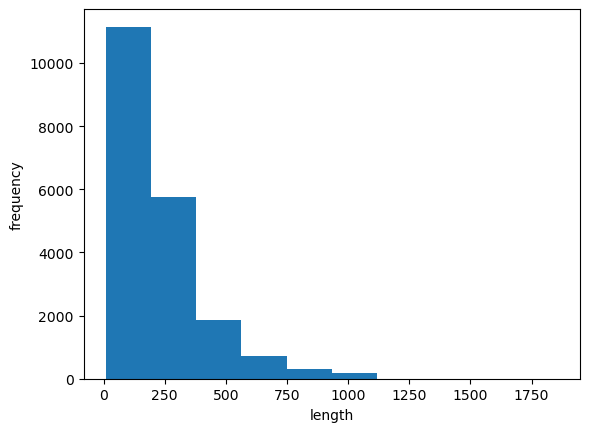

In [13]:
plt.hist(lengths)
plt.xlabel('length')
plt.ylabel('frequency')
plt.show()

- 대부분 리뷰 길이가 최소 250 이하임
- 평균이 중간값보다 높음에 따라 아주 큰 길이의 데이터가 있고, 왼쪽으로 치우쳐짐을 확인 할 수 있음 

- 리뷰는 대부분 짧아서 이 예제에서는 중간값보다 훨씬 짧은 100개의 단어만 사용
- 100개의 단어보다 작은 리뷰의 경우 0으로 패딩을 진행하여 길이를 100으로 맞춤

In [14]:
# 시퀀스 데이터의 길이를 맞추는 pad_sequences() 함수를 이용
train_seq = pad_sequences(train_input, maxlen=100)

In [15]:
print(train_seq.shape)

(20000, 100)


In [22]:
print(train_seq[0])

[ 10   4  20   9   2   2   2   5  45   6   2   2  33   2   8   2 142   2
   5   2  17  73  17   2   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12   2  69   2 142  73   2   6
   2   7   2   2 188   2 103  14  31  10  10   2   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10   2 158]


In [17]:
print(train_input[0][-10:])

[6, 2, 46, 7, 14, 20, 10, 10, 2, 158]


In [ ]:
# 샘플 길이가 100이 안되는 경우
print(train_seq[5])

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2   2   2 183  10
  10  13  82  79   4   2  36  71   2   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14   2  56 129   2  10  10  21   2  94   2   2   2   2  11 190
  24   2   2   7  94   2   2  10  10  87   2  34  49   2   7   2   2   2
   2   2   2   2  46  48  64  18   4   2]


In [19]:
val_seq = pad_sequences(val_input, maxlen=100)

- Sequential 클래스는 순환 신경망뿐만 아니라 합성곱 신경망이나 일반적인 인공 신경망 모델을 모두 만들 수 있음
- 다만 층을 순서대로 쌓기 때문에 Sequential 클래스로 이름을 붙임에 따라 순차 데이터(sequential data)와는 관련이 없음

### 신경망 구축

In [20]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,200)))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

I0000 00:00:1764675117.563000  562456 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


- Dense나 Conv2D 클래스 대신 SimpleRNN 클래스를 
- Input 함수의 입력 차원을 (100, 200)으로 지정한 이유는 샘플의 길이가 100이기 때문

In [23]:
# 원-핫 인코딩 진행
# - 원-핫 인코딩은 정숫값을 배열에서 해당 정수 위치의 원소만 1이고 나머지는 모두 0으로 변환
train_oh = keras.utils.to_categorical(train_seq)

In [24]:
print(train_oh.shape)

(20000, 100, 200)


- `train_seq[0]` 의 첫번째 토큰인 10을 원-핫 인코딩으로 바꾸면 열한 번째 원소만 1 이고 나머지는 모두 0인 길이 200짜리 배열이 생성됨
- 정수 하나마다 모두 200차원의 배열로 변경되었기 때문에(20000, 100)크기의 `train_seq`가 
(20000, 100, 200)크기의 `train_oh`로 바뀜

In [ ]:
print(np.sum(train_oh[0][0])) # 1이 한개만 들어있으니 다 더하면 1.0

1.0


In [32]:
print(train_oh[0][0][:13]) # 11번째 자리 1인걸 확인
print(type(train_oh[0][0][12]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
<class 'numpy.float64'>


In [33]:
val_oh = keras.utils.to_categorical(val_seq)

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         1,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,681 (6.57 KB)

 Trainable params: 1,681 (6.57 KB)

 Non-trainable params: 0 (0.00 B)

- SimpleRNN에 전달할 샘플의 크기는 (100, 200)이지만 이 순환층은 마지막 타임스텝의 은닉 상태만 출력
- 이 때문에 출력 크기가 순환층의 뉴런 개수와 동일한 8임을 확인
- 입력 토큰은 200차원의 원-핫 인코딩 배열로 이 배열이 순환층의 뉴런 8개와 완전히 연결되기 때문에 총 $200 \times 8 = 1,600$개의 가중치가 존재
- 순환층의 은닉 상태는 다시 다음 타임스텝에 사용되기 위해 또 다른 가중치와 곱해짐
- 이 은닉 상태도 순환층의 뉴런과 연결 되기 때문

- 순환층의 은닉 상태는 다시 다음 타임스텝에 사용되기 위해 또 다른 가중치와 곱해짐
- 이 은닉 상태도 순환층의 뉴런과 완전히 연결되기 때문에 $8 (은닉\ 상태\ 크기) \times 8 (뉴런개수) = 64$ 개의 가중치가 필요합니다. 마지막으로 뉴런마다 하나의 절편이 있습니다. 따라서 모두 $1,600 + 
64 + 8 = 1,672$개의 모델 파라미터가 필요

### 신경망 훈련
- 기본적인 Keras 사용방법과 같음
- 노트북 성능에 따라 GPU 메모리에 올릴 수 없어 에포크는 10, 배치 사이즈는 8로 지정

In [35]:
model.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-simplernn-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model.fit(train_oh, train_target, epochs=10, batch_size=8,
                    validation_data=(val_oh, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/10
1819/2500 ━━━━━━━━━━━━━━━━━━━━ 1:04 94ms/step - accuracy: 0.5023 - loss: 0.6995

KeyboardInterrupt: 

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

NameError: name 'history' is not defined

In [36]:
print(train_seq.nbytes, train_oh.nbytes)

8000000 3200000000


### 단어 임베딩 word embedding 사용
- 단어 임베딩은 각 단어를 고정된 크기의 실수 벡터로 바꿈
- 원-핫 인코딩된 벡터보다 훨씬 의미 있는 값으로 채워져 있어 자연어 처리에서 더 좋은 성능을 내는 경우가 있음
- 또한 입력으로 정수 데이터를 받아 시퀀싱 배열을 그대로 사용 할 수 있음
- 메모리를 절약하고 더 많은 단어를 사용할 수 있음

In [37]:
(train_input, train_target), (test_input, test_target) = imdb.load_data(
    num_words=500)
train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size=0.2, random_state=42)
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [38]:
model_emb = keras.Sequential()
model_emb.add(keras.layers.Input(shape=(100,)))
model_emb.add(keras.layers.Embedding(500, 16))
model_emb.add(keras.layers.SimpleRNN(8))
model_emb.add(keras.layers.Dense(1, activation='sigmoid'))

In [39]:
model_emb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,209 (32.07 KB)

 Trainable params: 8,209 (32.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_emb.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-embedding-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)

history = model_emb.fit(train_seq, train_target, epochs=100, batch_size=64,
                        validation_data=(val_seq, val_target),
                        callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100


2025-11-30 19:53:36.353483: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5242 - loss: 0.6914

2025-11-30 19:54:43.309564: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 225ms/step - accuracy: 0.5489 - loss: 0.6863 - val_accuracy: 0.5782 - val_loss: 0.6750
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 222ms/step - accuracy: 0.6745 - loss: 0.6070 - val_accuracy: 0.7178 - val_loss: 0.5697
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 71s 227ms/step - accuracy: 0.7492 - loss: 0.5251 - val_accuracy: 0.6626 - val_loss: 0.6421
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 229ms/step - accuracy: 0.7533 - loss: 0.5171 - val_accuracy: 0.7524 - val_loss: 0.5283
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - accuracy: 0.7729 - loss: 0.4896 - val_accuracy: 0.7442 - val_loss: 0.5318
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 205ms/step - accuracy: 0.7911 - loss: 0.4630 - val_accuracy: 0.7542 - val_loss: 0.5229
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 237ms/step - accuracy: 0.7992 - loss: 0.4494 - val_accuracy: 0.7528 - val_loss: 0.5251
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 233ms/step - accuracy: 0.8093 - loss: 0.433

- laptop wsl환경내 4gb rtx  3050 gpu 기준 14분 걸림

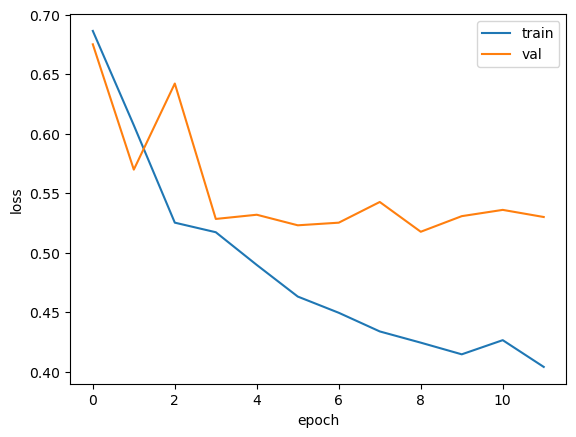

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

## 09-3 LSTM GRU 셀
- 성능 뛰어나고, SimpleRNN보다 계산이 복잡
- 일반 RNN은 시퀀스가 길수록 순환되는 은닉 상태에 담긴 정보가 점차 희석
- 이에 떨어져 있는 단어 정보를 인식하기 위해 LSTM GRU 셀개 개발 됨

### LSTM Long Short-Term Memory
- 단기 기억을 오래 기억하기 위해 고안
- 입력과 가중치를 곱하고 절편을 더해 활성화 함수를 통과시키는 구조를 여러 개 가지고 있고 이런 계산 결과는 다음 타임스텝에 재사용
- 총 4개의 작은 셀들이 존재


<center>
<img src="./appendix/ch9/image-7.png" />
</center>

- 기호 
    - $w_o$ : 은닉 상태를 계산할 때 사용하는 가중치 $w_x$와 $w_h$
    - X : 곱셈
    - 파란 동그라미 : tanh 함수
    - 주황색 동그라미 : 시그모이드 함수
    - $w_j$, $w_i$, $w_f$ : 가중치
    - 녹색 $c$ : 셀 상태
    - 보라색 $h$ : 은닉 상태

- LSTM에는 순환되는 상태가 2개 : 은닉 상태, 셀 상태 cell state 존재
- 셀 상태 계산 과정
    1) 입력과 은닉 상태를 또 다른 가중치 $w_f$ 에 곱한 다음 시그모이드 함수를 통과
    2) 이전 타임스텝의 셀 상태와 곱하여 새로운 셀 상태를 생성\
        (오른쪽에서 tanh 함수를 통과하여 새로운 은닉 상태를 만듦)
    3) 입력과 은닉 상태를 각기 다른 가중치에 곱한 다음, 하나는 시그모이드 함수를 통과시키고 다른 하나는 tanh 함수를 통과
    4) 그다음 두 결과를 곱한 후 이전 셀 상태와 더함

- 출력 게이트 종류
- 삭제 게이트 : 셀 상태에 있는 정보를 제거하는 역할
- 입력 게이트 : 새로운 정보를 셀 상태에 추가
- 출력 게이트 : 입력 게이트를 거친 셀 상태가 다음은닉 상태로 출력됩

In [5]:
(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words=500)
train_input, val_input, train_target, val_target =\
      train_test_split(train_input, train_target, test_size=0.2, random_state=42)

In [6]:
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)

In [7]:
model_lstm = keras.Sequential()
model_lstm.add(keras.layers.Input(shape=(100,)))
model_lstm.add(keras.layers.Embedding(500, 16))
model_lstm.add(keras.layers.LSTM(8))
model_lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_lstm.summary()

I0000 00:00:1764747794.287367   13523 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1754 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 4GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,809 (34.41 KB)

 Trainable params: 8,809 (34.41 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 컴퓨터 환경에 따라 배치 사이즈를 줄여서 진행
model_lstm.compile(optimizer='adam', loss='binary_crossentropy',
                   metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-lstm-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
                         validation_data=(val_seq, val_target),
                         callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100


2025-12-03 16:43:17.596958: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
2025-12-03 16:43:19.349438: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6049 - loss: 0.6483

2025-12-03 16:43:25.729183: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6867 - loss: 0.5841 - val_accuracy: 0.7632 - val_loss: 0.4904
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7861 - loss: 0.4689 - val_accuracy: 0.7874 - val_loss: 0.4554
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7975 - loss: 0.4448 - val_accuracy: 0.7922 - val_loss: 0.4433
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8030 - loss: 0.4307 - val_accuracy: 0.7944 - val_loss: 0.4417
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8055 - loss: 0.4216 - val_accuracy: 0.7976 - val_loss: 0.4376
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8099 - loss: 0.4139 - val_accuracy: 0.7988 - val_loss: 0.4356
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8122 - loss: 0.4077 - val_accuracy: 0.8000 - val_loss: 0.4329
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8135 - loss: 0.4026 - val_accuracy

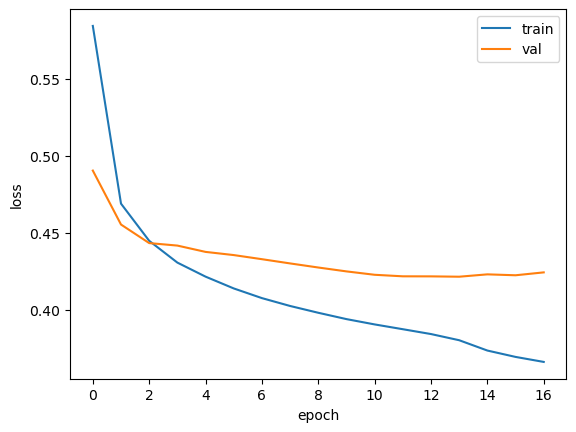

In [9]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### 순환층 드랍아웃 적용
-  드롭아웃은 은닉층에 있는 뉴런의 출력을 랜덤하게 꺼서 과대적합을 막는 기법

In [10]:
model_dropout = keras.Sequential()
model_dropout.add(keras.layers.Input(shape=(100,)))
model_dropout.add(keras.layers.Embedding(500, 16))
model_dropout.add(keras.layers.LSTM(8, dropout=0.2))
model_dropout.add(keras.layers.Dense(1, activation='sigmoid'))

In [11]:
model_dropout.compile(optimizer='adam', loss='binary_crossentropy',
                      metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-dropout-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_dropout.fit(train_seq, train_target, epochs=100, batch_size=64,
                            validation_data=(val_seq, val_target),
                            callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100


2025-12-03 16:46:20.404306: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5843 - loss: 0.6670

2025-12-03 16:46:26.767766: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6592 - loss: 0.6154 - val_accuracy: 0.7662 - val_loss: 0.5078
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7638 - loss: 0.4981 - val_accuracy: 0.7800 - val_loss: 0.4715
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7872 - loss: 0.4602 - val_accuracy: 0.7896 - val_loss: 0.4597
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7987 - loss: 0.4398 - val_accuracy: 0.7980 - val_loss: 0.4393
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8041 - loss: 0.4262 - val_accuracy: 0.8024 - val_loss: 0.4361
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8060 - loss: 0.4205 - val_accuracy: 0.7982 - val_loss: 0.4355
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8105 - loss: 0.4136 - val_accuracy: 0.7952 - val_loss: 0.4423
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8114 - loss: 0.4130 - val_accuracy

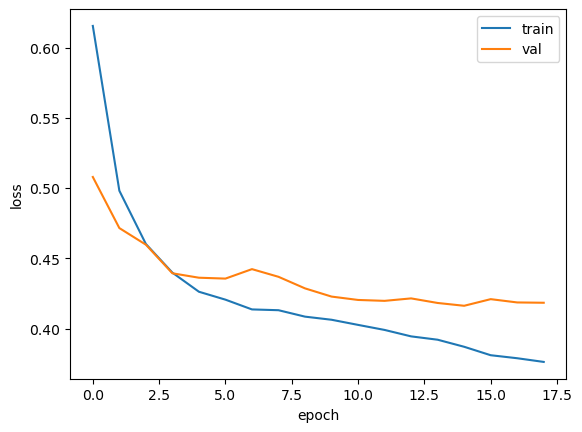

In [12]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### 2개 층 연결
- 순환층의 은닉 상태는 샘플의 마지막 타임스텝에 대한 은닉 상태만 다음 층으로 전달해야함
- 하지만 순환층을 쌓게 되면 모든 순환층에 순차 데이터가 필요함에 따라 앞쪽의 순환층이 모든 타임스텝에 대한 은닉 상태를 출력해야 함
- 오직 마지막 순환층만 마지막 타임스텝의 은닉 상태를 출력

In [13]:
model_2lstm = keras.Sequential()
model_2lstm.add(keras.layers.Input(shape=(100,)))
model_2lstm.add(keras.layers.Embedding(500, 16))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2, return_sequences=True))
model_2lstm.add(keras.layers.LSTM(8, dropout=0.2))
model_2lstm.add(keras.layers.Dense(1, activation='sigmoid'))
model_2lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 8)         │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 8)              │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,353 (36.54 KB)

 Trainable params: 9,353 (36.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model_2lstm.compile(optimizer='adam', loss='binary_crossentropy',
                     metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-2lstm-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_2lstm.fit(train_seq, train_target, epochs=100, batch_size=64,
                          validation_data=(val_seq, val_target),
                          callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100


2025-12-03 16:49:04.772158: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6151 - loss: 0.6342

2025-12-03 16:49:15.003046: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.6923 - loss: 0.5744 - val_accuracy: 0.7730 - val_loss: 0.4798
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7770 - loss: 0.4796 - val_accuracy: 0.7872 - val_loss: 0.4487
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7883 - loss: 0.4606 - val_accuracy: 0.7890 - val_loss: 0.4486
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.7982 - loss: 0.4461 - val_accuracy: 0.7858 - val_loss: 0.4476
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8008 - loss: 0.4363 - val_accuracy: 0.7904 - val_loss: 0.4424
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8046 - loss: 0.4288 - val_accuracy: 0.7884 - val_loss: 0.4515
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8095 - loss: 0.4230 - val_accuracy: 0.7980 - val_loss: 0.4400
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.8130 - loss: 0.4144 - val_accura

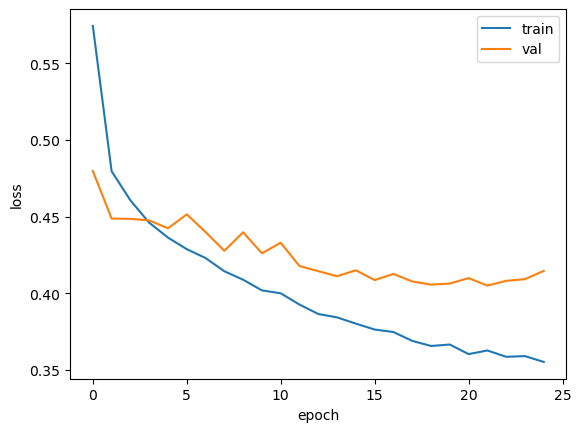

In [15]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

### GRU 신경망 Gated Recurrent Unit
- LSTM을 간소화한 버전
- LSTM보다 가중치가 적기 때문에 계산량이 적지만 LSTM 못지않은 좋은 성능을 냄
- LSTM처럼 셀 상태를 계산하지 않고 은닉 상태 하나만 포함


<center><img src='./appendix/ch9/image-8.png'></center>

- GRU 셀에는 은닉 상태와 입력에 가중치를 곱하고 절편을 더하는 작은 셀이 3개 있음
- 2개는 시그모이드 활성화 함수를 사용하고 하나는 tanh 활성화 함수를 사용

In [16]:
model_gru = keras.Sequential()
model_gru.add(keras.layers.Input(shape=(100,)))
model_gru.add(keras.layers.Embedding(500, 16))
model_gru.add(keras.layers.GRU(8, dropout=0.2))
model_gru.add(keras.layers.Dense(1, activation='sigmoid'))
model_gru.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 16)        │         8,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,633 (33.72 KB)

 Trainable params: 8,633 (33.72 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model_gru.compile(optimizer='adam', loss='binary_crossentropy',
                  metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-gru-model.keras',
                                                save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3,
                                                  restore_best_weights=True)
history = model_gru.fit(train_seq, train_target, epochs=100, batch_size=64,
                        validation_data=(val_seq, val_target),
                        callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100


2025-12-03 16:56:10.837750: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5613 - loss: 0.6739

2025-12-03 16:56:17.231151: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6392 - loss: 0.6230 - val_accuracy: 0.7544 - val_loss: 0.5090
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7693 - loss: 0.4873 - val_accuracy: 0.7550 - val_loss: 0.5049
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7887 - loss: 0.4595 - val_accuracy: 0.7804 - val_loss: 0.4637
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7977 - loss: 0.4421 - val_accuracy: 0.7910 - val_loss: 0.4469
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8025 - loss: 0.4323 - val_accuracy: 0.7918 - val_loss: 0.4423
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8054 - loss: 0.4254 - val_accuracy: 0.8022 - val_loss: 0.4310
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8087 - loss: 0.4207 - val_accuracy: 0.8038 - val_loss: 0.4295
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8116 - loss: 0.4163 - val_accurac

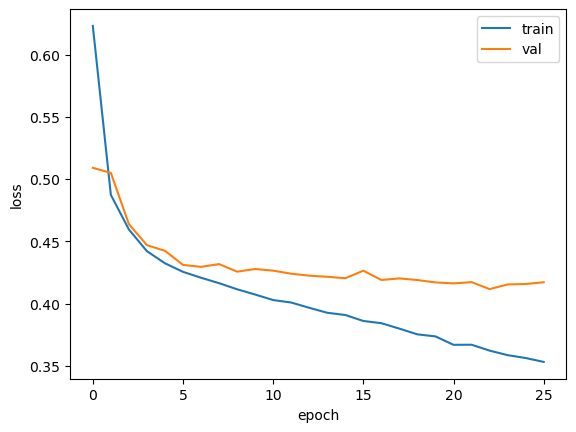

In [18]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [19]:
test_seq = pad_sequences(test_input, maxlen=100)
best_model = keras.models.load_model('best-gru-model.keras')
best_model.evaluate(test_seq, test_target)

2025-12-03 16:59:37.558728: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8184 - loss: 0.4019


[0.40190589427948, 0.8184400200843811]